## Import

importing the required libraries ,import a skit-learn as we needed it 

In [1008]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## Load Raw Data

we using a pandas to load are raw data from property.csv file

In [1009]:
df_raw =pd.read_csv('../Data/raw/Property.csv',sep=';')
df=df_raw.copy()



**check the head,describe and info of data**

In [1010]:
df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,NaN,NaN


*there is the lot of null value in agency ang agent column but we don't need these columns for prediction ,we drop that columns*

In [1011]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 191393 entries, 0 to 191392
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    191393 non-null  int64  
 1   location_id    191393 non-null  int64  
 2   page_url       191393 non-null  str    
 3   property_type  191393 non-null  str    
 4   price          191393 non-null  int64  
 5   location       191393 non-null  str    
 6   city           191393 non-null  str    
 7   province_name  191393 non-null  str    
 8   latitude       191393 non-null  float64
 9   longitude      191393 non-null  float64
 10  baths          191393 non-null  int64  
 11  area           191393 non-null  str    
 12  purpose        191393 non-null  str    
 13  bedrooms       191393 non-null  int64  
 14  date_added     191393 non-null  str    
 15  agency         144014 non-null  str    
 16  agent          144013 non-null  str    
dtypes: float64(2), int64(5), str(10)
memory 

In [1012]:
df.describe()

,property_id,location_id,price,latitude,longitude,baths,bedrooms
count,1.913930e+05,191393.000000,1.913930e+05,191393.000000,191393.000000,191393.000000,191393.000000
mean,1.573170e+07,4224.580350,1.644655e+07,30.104593,71.572992,2.865956,3.171516
std,2.215249e+06,3719.125201,3.416412e+07,3.645941,3.080463,2.435332,1.952403
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000
25%,1.511867e+07,1057.000000,8.000000e+04,24.972287,67.152597,0.000000,2.000000
50%,1.676385e+07,3233.000000,7.300000e+06,31.463563,73.077743,3.000000,3.000000
75%,1.715282e+07,7182.000000,1.800000e+07,33.550869,74.228218,4.000000,4.000000
max,1.769386e+07,14246.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000


## Cleaning Data

there is no null value in all columns except(agency,agent) columns but there is zero values in some columns

In [1013]:
zero_counts=(df == 0).sum()
zero_counts

property_id          0
location_id          0
page_url             0
property_type        0
price                3
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths            48130
area                 0
purpose              0
bedrooms         24959
date_added           0
agency               0
agent                0
dtype: int64

In [1014]:
df['property_type'].value_counts()

property_type
House            118915
Flat              40157
Upper Portion     18475
Lower Portion     11693
Room               1029
Farm House          725
Penthouse           399
Name: count, dtype: int64

*For baths and bedrooms, we will replace 0 with NaN and then fill it with the median value of the respective property type.*


In [1015]:
# For baths
df['baths']=df['baths'].replace(0,np.nan)
df['baths']=df['baths'].fillna(df.groupby('property_type')['baths'].transform('median'))

# For bedrooms

df['bedrooms']=df['bedrooms'].replace(0,np.nan)
df['bedrooms']=df['bedrooms'].fillna(df.groupby('property_type')['bedrooms'].transform('median'))



*remove a zeros from price column*

In [1016]:
 
df = df[df['price']>0]
print((df['price']==0).sum())




0


**we clean all the data form zero and null values.**


In [1017]:
zero =(df == 0).sum()
zero

property_id      0
location_id      0
page_url         0
property_type    0
price            0
location         0
city             0
province_name    0
latitude         0
longitude        0
baths            0
area             0
purpose          0
bedrooms         0
date_added       0
agency           0
agent            0
dtype: int64

In [1018]:
df.value_counts('area')

area
1 Kanal        25452
5 Marla        24238
10 Marla       21874
8 Marla        10814
4 Marla         7528
               ...  
125 Kanal          1
153 Kanal          1
200 Kanal          1
4.9 Kanal          1
122.5 Kanal        1
Name: count, Length: 352, dtype: int64

**we covert the area into two sperate columns value_area and unit_area so we easily convert the area columns that are in two unit (kanal,Marla) caonvert them into a standard unit Marla**

In [1019]:
# splitting area into value and unit
df[['value_area','unit_area']]=df['area'].str.split(" ",expand=True) 

# cleaning value_area and converting to numeric
df["value_area"] = df["value_area"].str.replace(r"[^\w\s\.]", "", regex=True)
df['value_area'] = pd.to_numeric(df['value_area'])

# removing rows with zero or negative area
df =df[df['value_area']>0]

# converting area to marla
df["area_marla"] = df["value_area"]
df.loc[df["unit_area"] == "Kanal", "area_marla"] = df["value_area"] * 20






*Drop the columns that are unnessary for prediction for this project*

In [1020]:
df=df.drop(columns=['area','value_area','unit_area','agency','agent'])
df=df.drop(columns=['page_url'])


In [1021]:
df['area_marla'].describe()

count    191374.000000
mean         14.574059
std         443.365114
min           0.100000
25%           4.900000
50%           7.600000
75%          12.000000
max      124444.000000
Name: area_marla, dtype: float64

*remove the area_marla rows that below the 1 marla*

In [1022]:

df=df[~(df['area_marla']<1)]

*Remove all the rows where area is greater than 2000 Marla except farm House*

In [1023]:
df = df[~(
    (df['area_marla'] > 2000) &
    (df['property_type'].isin(['House', 'Flat', 'Upper Portion', 'Lower Portion']))
)]


In [1024]:

df.shape

(191099, 14)

*there is many property that for rent but we need a for sale property for this project so we drop all the rows hows purpose is for rent*

In [1025]:
df =df[df['purpose']=='For Sale']
df.shape


(126966, 14)

**Remove all  the rows those have a price lower than 1 million ruppess and above than 500 million ruppess**

In [1026]:
df = df[~(
    (df['price']<1000000) |
    (df['price']==500000000) )]
df.shape

(126631, 14)

In [1027]:
df['price'].describe()

count    1.266310e+05
mean     2.476764e+07
std      3.925367e+07
min      1.000000e+06
25%      7.500000e+06
50%      1.350000e+07
75%      2.600000e+07
max      2.000000e+09
Name: price, dtype: float64

In [1028]:
df['location'].nunique()

1460

In [1029]:
df['location'].value_counts().head(10)

location
DHA Defence               16524
Bahria Town Karachi        7677
Bahria Town                6466
Gulistan-e-Jauhar          4729
Bahria Town Rawalpindi     4279
Gulshan-e-Iqbal Town       3221
Gadap Town                 2706
Scheme 33                  2524
North Nazimabad            2412
North Karachi              2380
Name: count, dtype: int64

In [1030]:
df['city'].value_counts()

city
Karachi       46479
Lahore        45118
Islamabad     17157
Rawalpindi    12687
Faisalabad     5190
Name: count, dtype: int64

In [1031]:
# mean almost double from median it means there is lot of outliers but i property daata set we can't consider this outliers* 
# 1. There is different property type like farm house are more expensive than any other property
# 2. there is 1459 diff location so property in f-10 Islamabad is more expensive than Fasilabad
# 3. we used a log to normalize all of this                                                                                                         


*Remove all the columns that we don't need for this project*

In [1032]:
df =df.drop(columns=['property_id', 'location_id', 'purpose', 'province_name', 'latitude', 'longitude','date_added'])

In [1033]:
df.head()

,property_type,price,location,city,baths,bedrooms,area_marla
0,House,220000000,Model Town,Lahore,5.0,4.0,120.0
1,House,40000000,Multan Road,Lahore,5.0,5.0,20.0
2,House,9500000,Eden,Lahore,5.0,3.0,9.0
3,House,125000000,Gulberg,Lahore,7.0,8.0,20.0
4,House,21000000,Allama Iqbal Town,Lahore,5.0,6.0,11.0


**Saved clean data in clean_property.csv**

In [1034]:
df.to_csv('../Data/cleaned/clean_property.csv')

## Exploratry Data Analysis

*lets explore the data thorugh visulization*

**we make a pplot with log function and without a log function show the diff how much log transforamtion important for this project**

In [1035]:
# mean almost double from median it means there is lot of outliers but i property daata set we can't consider this outliers

# how data looked skewed and we used log to normalize it

# reason for outliers in property data set

# 1. There is different property type like farm house are more expensive than any other property
# 2. there is 1459 diff location so property in f-10 Islamabad is more expensive than Fasilabad
# 3. we used a log to normalize all of this 

***Before Log***

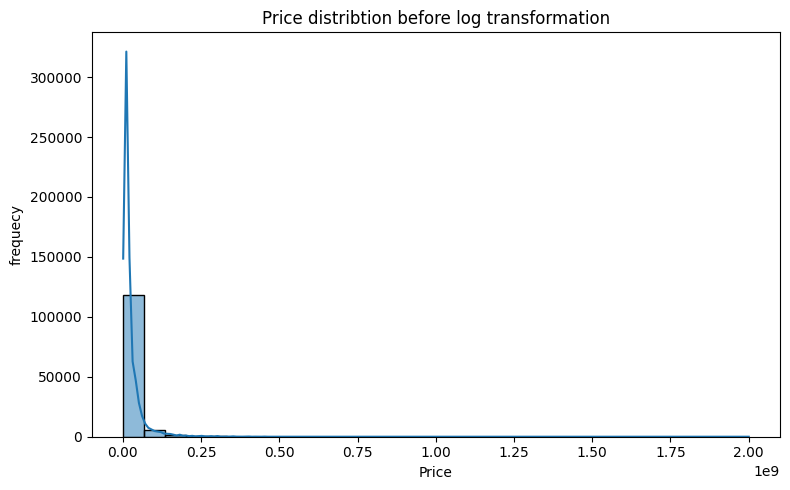

In [1036]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'],bins=30,kde=True)

plt.xlabel('Price')
plt.ylabel('frequecy')
plt.title('Price distribtion before log transformation')
plt.tight_layout()


**After Log()**

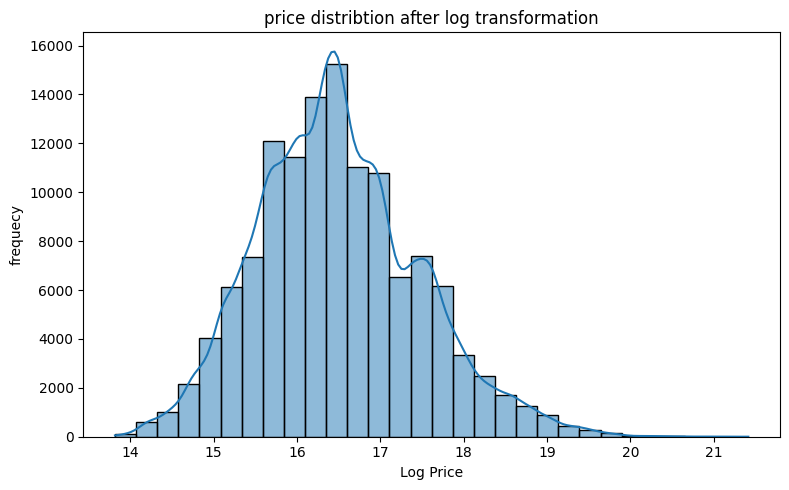

In [1037]:
plt.figure(figsize=(8,5))

sns.histplot(np.log(df['price']),bins=30,kde=True)

plt.xlabel('Log Price')
plt.ylabel('frequecy')  
plt.title('price distribtion after log transformation')
plt.tight_layout()

**Box plot for price and cities showing outliers in price for different cities**

**Before Log**

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Lahore'),
  Text(1, 0, 'Karachi'),
  Text(2, 0, 'Islamabad'),
  Text(3, 0, 'Faisalabad'),
  Text(4, 0, 'Rawalpindi')])

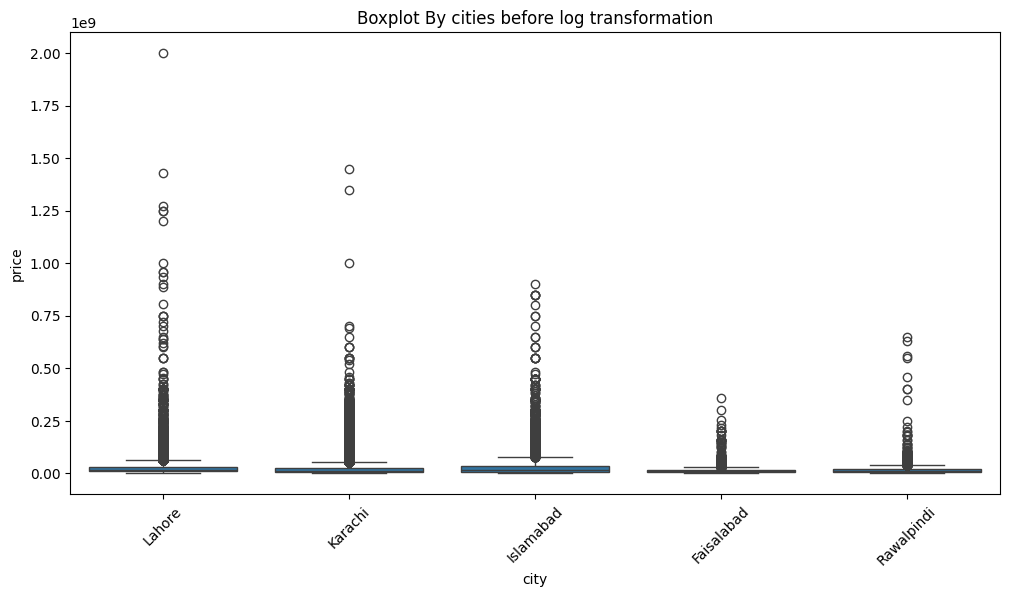

In [1038]:
plt.figure(figsize=(12,6))

sns.boxplot(x='city',y='price',data=df)

plt.title('Boxplot By cities before log transformation')
plt.xticks(rotation=45)


In [1039]:
# Islamabad has highest price variation — mix of expensive 
# sectors (F-6, F-7) and affordable areas
# Faisalabad is the most affordable major city in the dataset

Text(0.5, 1.0, 'Boxplot By cities after log transformation')

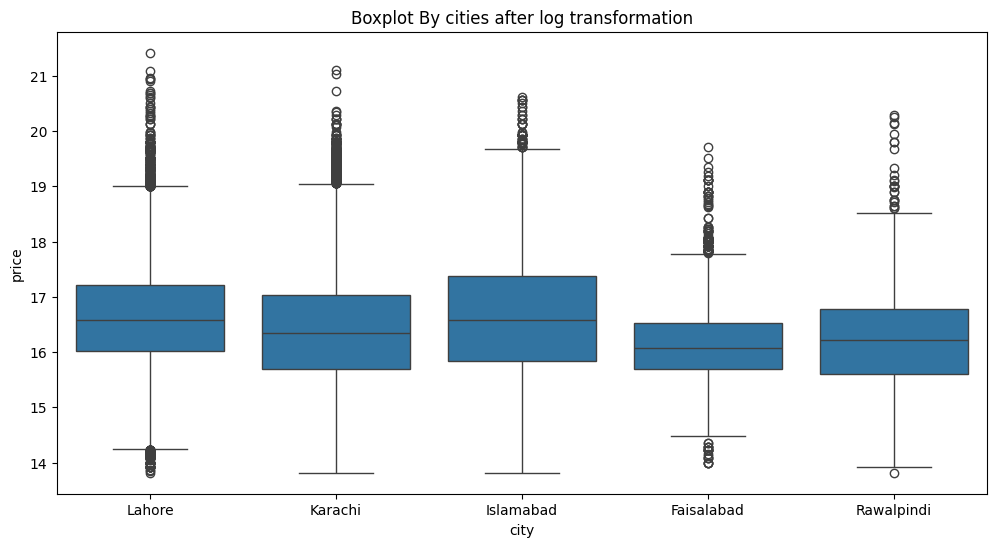

In [1040]:
# Boxplot for cities after log transformation
plt.figure(figsize=(12,6))
sns.boxplot(x='city',y=np.log(df['price']),data=df)
plt.title('Boxplot By cities after log transformation')



In [1041]:
# after log transformation data is more normally distributed and we can use it for modeling


***Boxplot for a diff property_types**

In [1042]:
# boxplot for property type without log transformation

Text(0.5, 1.0, 'Boxplot By Property Type before log transformation')

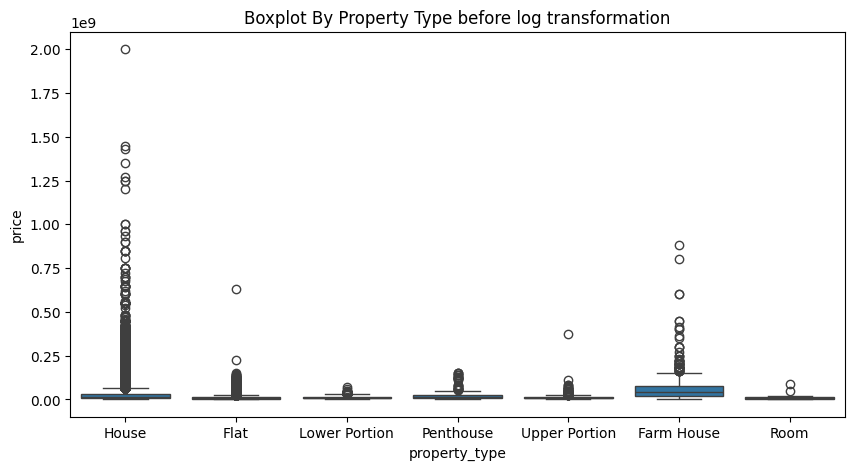

In [1043]:
plt.figure(figsize=(10,5))

sns.boxplot(x='property_type',y='price',data=df)

plt.title('Boxplot By Property Type before log transformation')

**After Log()**

Text(0.5, 1.0, 'Boxplot By Property Type after log transformation')

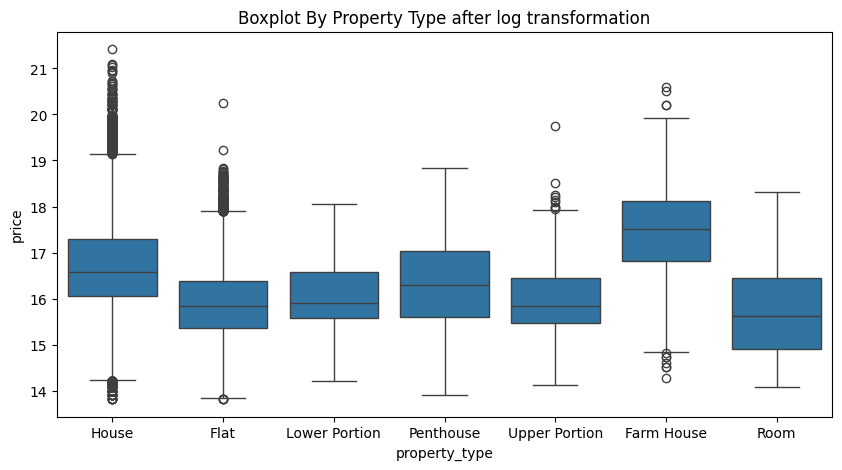

In [1044]:
# Boxplot by property type after log transformation
plt.figure(figsize=(10,5))
sns.boxplot(x='property_type',y=np.log(df['price']),data=df)
plt.title('Boxplot By Property Type after log transformation')

**remove a room row because they have a very less prices and less in numbers**

In [1045]:
df['property_type'].value_counts()

property_type
House            93695
Flat             28386
Upper Portion     2623
Lower Portion      992
Farm House         619
Penthouse          295
Room                21
Name: count, dtype: int64

In [1046]:
df = df[df['property_type']!='Room']


**Heatmap for correlation before log transformation**

Text(0.5, 1.0, 'Correlation Heatmap before Log Transformation')

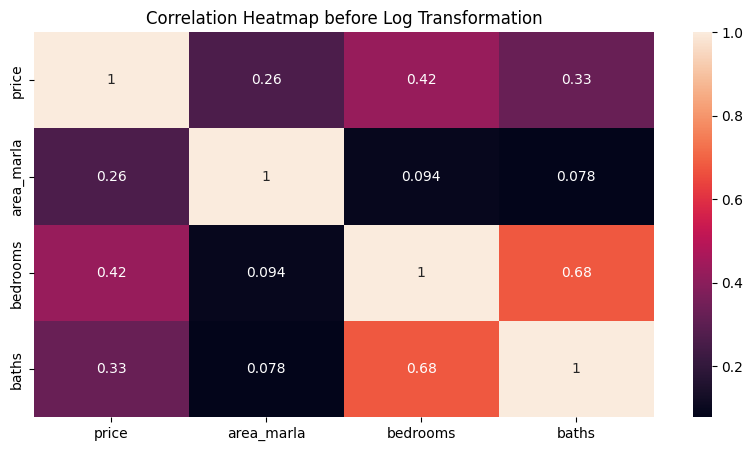

In [1047]:
cols = ['price','area_marla','bedrooms','baths']

plt.figure(figsize=(10,5))
sns.heatmap(df[cols].corr(),annot=True)
plt.title('Correlation Heatmap before Log Transformation')


## Feature Enginering

**Make a new columns of price and area marla and covert into in og form for normalization using in modeling**

In [1048]:
df['price_log']=np.log(df['price'])
df['area_log']=np.log(df['area_marla'])


**Using a One Hot Encoding Method for city and Property_type**

In [1049]:
df =pd.get_dummies(df,columns=['city','property_type'],dtype=int,drop_first=True)


**Using a target encoding Method bcz location have 1459 unique areas**

In [1050]:
df['location_encoded']=df.groupby('location')['price'].transform('median')


In [1051]:
df =df.drop(columns=['location'])


In [1052]:
df.columns

Index(['price', 'baths', 'bedrooms', 'area_marla', 'price_log', 'area_log',
       'city_Islamabad', 'city_Karachi', 'city_Lahore', 'city_Rawalpindi',
       'property_type_Flat', 'property_type_House',
       'property_type_Lower Portion', 'property_type_Penthouse',
       'property_type_Upper Portion', 'location_encoded'],
      dtype='str')

In [1053]:
df.head()

,price,baths,bedrooms,area_marla,price_log,area_log,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi,property_type_Flat,property_type_House,property_type_Lower Portion,property_type_Penthouse,property_type_Upper Portion,location_encoded
0,220000000,5.0,4.0,120.0,19.209138,4.787492,0,0,1,0,0,1,0,0,0,55000000.0
1,40000000,5.0,5.0,20.0,17.504390,2.995732,0,0,1,0,0,1,0,0,0,6500000.0
2,9500000,5.0,3.0,9.0,16.066802,2.197225,0,0,1,0,0,1,0,0,0,10500000.0
3,125000000,7.0,8.0,20.0,18.643824,2.995732,0,0,1,0,0,1,0,0,0,32750000.0
4,21000000,5.0,6.0,11.0,16.860033,2.397895,0,0,1,0,0,1,0,0,0,17000000.0


Text(0.5, 1.0, 'Correlation Heatmap after feature engineering')

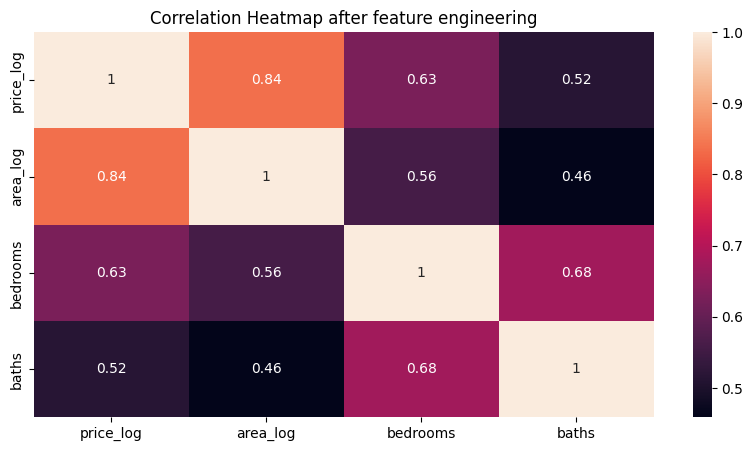

In [1054]:
# heatmap shows that price is positively correlated with area, bedrooms and baths. This means that as the area, number of bedrooms and baths increase, the price of the property also tends to increase. The correlation is not very strong but it is still significant. This suggests that these features can be useful in predicting the price of a property.
cols = ['price_log','area_log','bedrooms','baths']
plt.figure(figsize=(10,5))
sns.heatmap(df[cols].corr(),annot=True)
plt.title('Correlation Heatmap after feature engineering')

## Training the Model


### Imports


In [1055]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

**Training and testing data**

In [1056]:
x =df.drop(columns=['price','price_log','area_marla'])
y =df['price_log']

y.shape

(126610,)

In [1057]:
X_train,X_test,y_train,y_test =train_test_split(
    x,y,
    test_size=0.2,
    random_state=42

)


**Train a model with training set**

In [1058]:
model=LinearRegression()
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Evulation


**use the test data to test our model**

In [1059]:
y_pred=model.predict(X_test)


In [1060]:
# checing a model through r2 score and mean squared error
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'R2 Score: {r2:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'Root Mean Squared Error: {rmse:.4f}')

R2 Score: 0.8281
Mean Squared Error: 0.1623
Root Mean Squared Error: 0.4029


In [1061]:
# R2 Score: 0.8281
# Mean Squared Error: 0.1623
# Root Mean Squared Error: 0.4029

# 1. R2 Score of 0.8281 indicates that approximately 82.81% of the variance in the target variable (price_log) can be explained by the features in the model. This suggests a good fit of the model to the data.

# 2. Mean Squared Error (MSE) of 0.1623 indicates that, on average, the squared difference between the predicted values and the actual values is 0.1623. A lower MSE indicates better model performance.

# 3. Root Mean Squared Error (RMSE) of 0.4029 indicates that, on average, the predicted values deviate from the actual values by approximately 0.4029 in the log scale. This can be interpreted as a measure of the average prediction error in the original price scale after exponentiating the predictions.


## Residuals

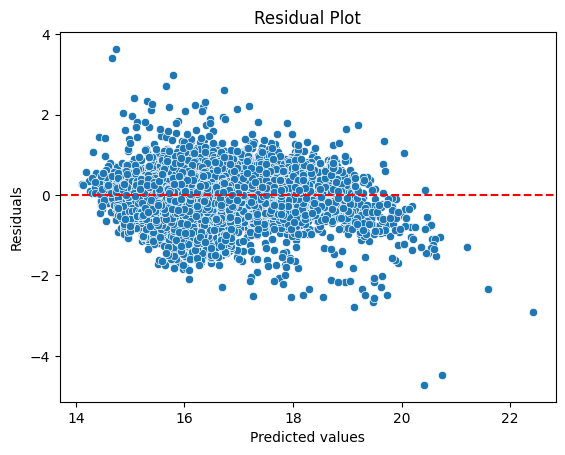

In [1062]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred,y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [1063]:
# Model performs well for mid-range properties
# Struggles with high value properties (heteroscedasticity)
# Suggests non-linear models (Random Forest, XGBoost) may perform better

# Conclusion 


## Project Conclusion

### What I Built
A house price prediction model for Pakistan's 5 major cities 
using Linear Regression on real Zameen.com data.

### Data Journey
- Started with 190k+ properties, ended with 126k after cleaning
- Biggest issue: 64k rent listings mixed with sale listings
- Cleaned zero values in baths/bedrooms using property type median
- Converted mixed area units (Kanal/Marla) to standard Marla

### Key Findings
- Islamabad has highest price variation across all cities
- Faisalabad is most affordable major city
- area_marla is strongest predictor of price (correlation: 0.8)
- Location is critical — same area size has 10x price difference by location

### Model Performance
- R² Score: 0.82 — model explains 82% of house price variation
- No overfitting — train and test scores almost equal
- Model struggles with luxury properties (above 50M)

### What Would Make It Better
- Try Random Forest or XGBoost for non-linear patterns
- Add more features like distance from city center
- Collect more luxury property data
- Deploy as web app for real time price estimation